# K562 H3K27ac Enhancer Classification with DNABERT-2
## Same Task, Different Foundation Model — BPE Tokenization Meets Genomics

**Third in the classification series — comparing GFM architectures on the same problem.**

---

### Connection to Previous Notebooks

| Notebook | Model | Architecture | Tokenization |
|----------|-------|-------------|-------------|
| **Regression** (NT) | Nucleotide Transformer 500M | Encoder-only transformer | 6-mer vocabulary |
| **Classification** (NT) | Nucleotide Transformer 500M | Encoder-only transformer | 6-mer vocabulary |
| **Classification** (HyenaDNA) | HyenaDNA medium-160k | State-space model (Hyena) | Character-level (1 nt = 1 token) |
| **This notebook** | **DNABERT-2 117M** | **Encoder-only transformer** | **BPE (learned subword)** |

### Why DNABERT-2?

DNABERT-2 represents a fundamentally different approach to DNA tokenization.
While Nucleotide Transformer uses a fixed k-mer vocabulary and HyenaDNA uses
single nucleotides, DNABERT-2 uses **Byte Pair Encoding (BPE)** — the same
tokenization strategy that powers GPT and BERT in NLP. This lets the model
learn its own variable-length "words" from DNA sequence data.

### What stays the same?
- Raw data (ENCODE K562 H3K27ac ChIP-seq)
- Biological question (enhancer vs non-enhancer)
- Chromosome-aware splits (train chr1-16, val chr17-18, test chr19-22+X)
- CNN baseline
- Staged fine-tuning strategy
- Evaluation metrics (AUROC, AUPRC, F1)

### Lecture Alignment

| Lecture Step | Section | DNABERT-2-Specific Notes |
|:---:|---|---|
| **0** | Biological question | Same binary classification |
| **1** | Model selection | **DNABERT-2: BPE tokenizer, 117M params** |
| **2** | Fine-tuning strategy | Same staged approach |
| **3** | Data curation | Same negative generation |
| **4-5** | Tokenization | **BPE — variable-length tokens, no k-mer bias** |
| **6** | Experimental setup | Same BCE loss + AUROC/AUPRC |
| **7** | Fine-tuning | Same staged approach |
| **8** | Evaluation | Same + cross-model comparison |

## The Biological Problem — Classification Framing

### Quick recap (see the NT classification notebook for the full discussion)

We want to predict whether a 1 kb DNA sequence from the human genome is an
**active enhancer** (marked by H3K27ac) or not, in K562 cells.

| Aspect | Detail |
|--------|--------|
| **Input** | 1 kb DNA sequence |
| **Output** | Binary: enhancer (1) or non-enhancer (0) |
| **Positive examples** | H3K27ac ChIP-seq peaks (~52k) |
| **Negative examples** | Random non-peak genomic regions (1:1 balanced) |
| **Resolution** | Locus-level, K562 cell line |

### Why try a different model on the same task?

> *Lecture: "Model selection is a hypothesis about what matters in your data."*

Each model encodes a different **inductive bias** about DNA:
- **NT** (k-mer tokenizer): assumes 6-mer units are meaningful — biologically motivated
  by codon structure and transcription factor binding sites
- **HyenaDNA** (character-level): makes no assumptions about token boundaries —
  lets the model learn all patterns from scratch
- **DNABERT-2** (BPE): learns a data-driven vocabulary — discovers which
  subsequences are statistically frequent and potentially meaningful

Comparing these models on the same task tells us whether tokenization strategy
matters for enhancer classification, or whether the biological signal is strong
enough that all approaches converge.

## Understanding DNABERT-2

### From DNABERT to DNABERT-2

The original **DNABERT** (2021) used overlapping k-mer tokenization:
the sequence `ACGTAC` with k=3 becomes `[ACG, CGT, GTA, TAC]`.
This creates **information leakage** between adjacent tokens (they share k-1 bases)
and requires choosing k upfront.

**DNABERT-2** (2024) fixes both issues with **Byte Pair Encoding (BPE)**:

| Feature | DNABERT (v1) | DNABERT-2 |
|---------|:---:|:---:|
| Tokenization | Overlapping k-mers | BPE (learned subword) |
| Vocabulary | Fixed by k | Learned from data |
| Token length | Fixed (k bases) | Variable (1 to ~20+ bases) |
| k choice needed? | Yes | No |
| Information leakage | Yes (k-1 overlap) | No |
| Parameters | ~110M | **117M** |
| Pre-training data | Human genome | Multi-species genomes |

### How BPE works on DNA

BPE starts with single-character tokens (A, C, G, T) and iteratively merges
the most frequent adjacent pairs:

```
Step 0: A C G T A C G T    (character level)
Step 1: A CG T A CG T      (CG is frequent → merge)
Step 2: A CGT A CGT         (CGT is frequent → merge)
...
```

The result is a vocabulary of variable-length tokens that reflect **statistical
regularities** in the training data. Frequent motifs become single tokens.

### Architecture details

- **Base model:** BERT-style encoder (12 transformer layers)
- **Parameters:** 117M (much smaller than NT-500M)
- **Hidden size:** 768
- **Pooling:** CLS token (like NT, unlike HyenaDNA which uses mean pooling)
- **Key requirement:** `trust_remote_code=True` for both tokenizer and model

In [1]:
# === INSTALLATION & DATA DOWNLOAD ===
# Same data as previous notebooks — skip if already downloaded
#!pip install -q torch transformers triton pyBigWig pandas numpy scikit-learn tqdm matplotlib seaborn captum pyfaidx
# Note: triton is needed by DNABERT-2's flash attention implementation

import os
if not os.path.exists('K562_H3K27ac.bigWig'):
    !wget -qO K562_H3K27ac.bigWig "https://www.encodeproject.org/files/ENCFF465GBD/@@download/ENCFF465GBD.bigWig"
if not os.path.exists('K562_peaks.bed'):
    !wget -qO K562_peaks.bed.gz "https://www.encodeproject.org/files/ENCFF038DDS/@@download/ENCFF038DDS.bed.gz" && gunzip -f K562_peaks.bed.gz
if not os.path.exists('hg38.fa'):
    !wget -qO hg38.fa.gz "https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz" && gunzip -f hg38.fa.gz && samtools faidx hg38.fa
print('Data files ready.')

Data files ready.


In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import pyBigWig
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoConfig
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             f1_score, accuracy_score, confusion_matrix,
                             roc_curve, precision_recall_curve)
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from captum.attr import IntegratedGradients
from pyfaidx import Fasta
from pathlib import Path
import importlib, sys, os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ============================================================
# DNABERT-2 loading workaround
# ============================================================
# DNABERT-2 ships custom model code (trust_remote_code=True).
# On newer transformers (>=4.40), AutoModel.from_pretrained() raises a
# ValueError due to a config-class mismatch between the library's
# BertConfig and the custom one bundled with the model.
# Fix: import the custom BertModel class directly from the cached code
# and call .from_pretrained() on it. No library changes needed.

def load_dnabert2_backbone(model_name):
    """Load DNABERT-2 backbone, working around the AutoModel config clash."""
    config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)

    # Locate the cached custom code
    cache_root = os.path.join(
        os.path.expanduser('~'), '.cache', 'huggingface', 'modules',
        'transformers_modules', 'zhihan1996', 'DNABERT-2-117M')
    revisions = [d for d in os.listdir(cache_root)
                 if os.path.isdir(os.path.join(cache_root, d))
                 and not d.startswith('_')]
    rev = revisions[0]

    parent = os.path.join(os.path.expanduser('~'), '.cache',
                          'huggingface', 'modules')
    if parent not in sys.path:
        sys.path.insert(0, parent)

    mod = importlib.import_module(
        f'transformers_modules.zhihan1996.DNABERT-2-117M.{rev}.bert_layers')
    model = mod.BertModel.from_pretrained(model_name, config=config)
    return model

print('DNABERT-2 loader ready.')

Device: cuda
DNABERT-2 loader ready.


In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================
QUICK_MODE = False

MODEL_NAME = "zhihan1996/DNABERT-2-117M"

if QUICK_MODE:
    MAX_PER_SPLIT = {'train': 5000, 'val': 1000, 'test': 2000}
    NUM_EPOCHS = 5
    BATCH_SIZE = 32
    print("QUICK_MODE: using data subset for faster training")
else:
    MAX_PER_SPLIT = {'train': None, 'val': None, 'test': None}
    NUM_EPOCHS = 10
    BATCH_SIZE = 32
    print("FULL MODE: using complete dataset")

NUM_UNFREEZE_LAYERS = 2
PATIENCE = 3
MAX_LENGTH = 512  # DNABERT-2 BPE tokenizer; 1kb DNA -> ~200-400 tokens typically

# Output directory
OUTPUT_DIR = Path('../../output/k562_dnabert2_classification')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

## Step 0 — Define the Biological Question

Same as the NT classification notebook:

> Given a 1 kb DNA sequence from the human genome, predict whether
> it overlaps an H3K27ac peak in K562 cells (active enhancer) or not.

The question doesn't change — only our **model hypothesis** changes.

### What we're really testing

By running the same experiment with DNABERT-2, we ask:

> *Does BPE tokenization capture enhancer-relevant patterns as well as
> k-mer tokenization (NT) or character-level input (HyenaDNA)?*

This is a direct test of Lecture Step 1: **"Does the model's inductive bias
match your biological question?"**

In [4]:
# ============================================================
# Step 0: Load raw data (identical to NT classification notebook)
# ============================================================

bw = pyBigWig.open('K562_H3K27ac.bigWig')

peaks = pd.read_csv('K562_peaks.bed', sep='\t', header=None, comment='#')
peaks.columns = ['chrom', 'start', 'end', 'name', 'score', 'strand',
                 'signal', 'pval', 'qval', 'peak']

peaks['summit'] = peaks['start'] + peaks['peak']
peaks['win_start'] = peaks['summit'] - 500
peaks['win_end'] = peaks['summit'] + 500

valid_chroms = ['chr' + str(i) for i in range(1, 23)] + ['chrX']
peaks = peaks[peaks.chrom.isin(valid_chroms)]
peaks = peaks[peaks.win_start >= 0]

genome = Fasta('hg38.fa')

def get_seq(chrom, start, end):
    try:
        return str(genome[chrom][start:end]).upper()
    except Exception:
        return None

peaks['sequence'] = peaks.apply(
    lambda r: get_seq(r.chrom, r.win_start, r.win_end), axis=1
)
peaks = peaks.dropna(subset=['sequence'])
peaks = peaks[peaks.sequence.apply(lambda s: s.count('N') / len(s) < 0.1)]
peaks = peaks.reset_index(drop=True)

print(f'Positive examples (H3K27ac peaks): {len(peaks):,}')

Positive examples (H3K27ac peaks): 52,315


## Step 1 — Model Selection: DNABERT-2 vs NT vs HyenaDNA

> *Lecture: "Always compare to a reasonable baseline, not just other FMs."*

### Architecture comparison

| Property | DNABERT-2 | NT-500M | HyenaDNA-medium |
|----------|:---------:|:-------:|:---------------:|
| **Parameters** | 117M | 500M | 14.2M |
| **Architecture** | BERT encoder | ESM-style encoder | State-space (Hyena) |
| **Layers** | 12 | 24 | 8 |
| **Hidden dim** | 768 | 1024 | 256 |
| **Tokenization** | BPE (learned) | 6-mer (fixed) | Character-level |
| **Tokens per 1kb** | ~200-400 | ~167 | 1000 |
| **Pooling** | CLS token | CLS token | Mean pooling |
| **Pre-training** | Multi-species | Human reference | Human reference |
| **Trust remote code** | Yes | No | Yes |

### Key insight: tokens per sequence

For a 1 kb sequence, different tokenizers produce very different numbers of tokens:
- **HyenaDNA:** 1000 tokens (1 per nucleotide) — longest sequence, finest resolution
- **DNABERT-2:** ~200-400 tokens (BPE merges frequent patterns) — adaptive
- **NT:** ~167 tokens (6-mer, non-overlapping) — fixed chunking

More tokens = more compute per sequence, but potentially finer-grained attention patterns.

In [5]:
# ============================================================
# Step 1: DNABERT-2 Classifier
# ============================================================
# Key differences from NT:
#   1. Uses load_dnabert2_backbone() helper (workaround for config clash)
#   2. Output is a tuple, not a named object — use out[0] for hidden states
#   3. 768-dim hidden size (vs 1024 for NT-500M)
#   4. 12 transformer layers (vs 24 for NT)

class GFMClassifier(nn.Module):
    """DNABERT-2 backbone + binary classification head.

    Output: raw logit (not probability). Use BCEWithLogitsLoss for training.
    Identical interface to the NT classifier — only the backbone differs.
    """
    def __init__(self, model_name, freeze_backbone=False):
        super().__init__()
        self.backbone = load_dnabert2_backbone(model_name)
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
        hidden = self.backbone.config.hidden_size  # 768 for DNABERT-2
        self.head = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
        )

    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids, attention_mask=attention_mask)
        # DNABERT-2 custom code returns a tuple, not a ModelOutput
        hidden_states = out[0]
        cls_repr = hidden_states[:, 0]  # CLS token
        return self.head(cls_repr).squeeze(-1)

In [6]:
# ============================================================
# Step 1: CNN Baseline Classifier (identical to NT notebook)
# ============================================================

def one_hot_encode(seq, length=1000):
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    encoded = np.zeros((4, length), dtype=np.float32)
    for i, base in enumerate(seq[:length]):
        if base in mapping:
            encoded[mapping[base], i] = 1.0
    return encoded

class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(4, 64, kernel_size=15, padding=7),
            nn.ReLU(), nn.BatchNorm1d(64), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=7, padding=3),
            nn.ReLU(), nn.BatchNorm1d(128), nn.MaxPool1d(4),
            nn.Conv1d(128, 64, kernel_size=5, padding=2),
            nn.ReLU(), nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.head(self.conv(x).squeeze(-1)).squeeze(-1)

## Step 2 — Fine-Tuning Strategy

Same staged approach as all previous notebooks:

1. **Stage 1 — Frozen backbone:** train classification head only
2. **Stage 2 — Partial unfreeze:** top 2 layers + differential LR

### DNABERT-2 fine-tuning considerations

With 117M parameters (vs NT's 500M), DNABERT-2 is much smaller.
This means:
- **Faster training** per epoch
- **Lower GPU memory** requirements
- Potentially **more benefit from unfreezing** more layers (less risk of overfitting
  per parameter compared to NT-500M)

> *Lecture: "Many papers overfit by fine-tuning huge backbones on tiny datasets."*
> With 117M params and ~50k examples, we have a better parameter-to-data ratio than NT.

## Step 3 — Data Curation: Generating Negative Examples

Same strategy as the NT classification notebook — random non-peak genomic regions,
1:1 balanced per chromosome. See that notebook for the full discussion on
negative sampling strategies and their implications.

In [7]:
# ============================================================
# Step 3: Generate negative examples (identical to NT notebook)
# ============================================================

chrom_sizes = {}
with open('hg38.fa.fai') as f:
    for line in f:
        parts = line.strip().split('\t')
        if parts[0] in valid_chroms:
            chrom_sizes[parts[0]] = int(parts[1])

BIN_SIZE = 500
occupied_bins = set()
for _, row in peaks.iterrows():
    for b in range(row.win_start // BIN_SIZE, row.win_end // BIN_SIZE + 1):
        occupied_bins.add((row.chrom, b))

def overlaps_peak(chrom, start, end):
    for b in range(start // BIN_SIZE, end // BIN_SIZE + 1):
        if (chrom, b) in occupied_bins:
            return True
    return False

np.random.seed(42)
pos_per_chrom = peaks.chrom.value_counts().to_dict()
negatives = []

print('Generating negative examples per chromosome...')
for chrom, n_pos in sorted(pos_per_chrom.items()):
    size = chrom_sizes.get(chrom, 0)
    if size < 2000:
        continue
    found = 0
    attempts = 0
    while found < n_pos and attempts < n_pos * 30:
        center = np.random.randint(500, size - 500)
        start, end = center - 500, center + 500
        if not overlaps_peak(chrom, start, end):
            negatives.append({'chrom': chrom, 'win_start': start, 'win_end': end})
            found += 1
        attempts += 1
    print(f'  {chrom}: {found:,} negatives (from {n_pos:,} positives)')

neg_df = pd.DataFrame(negatives)
print(f'\nTotal negatives generated: {len(neg_df):,}')

Generating negative examples per chromosome...
  chr1: 5,221 negatives (from 5,221 positives)
  chr10: 2,304 negatives (from 2,304 positives)
  chr11: 2,885 negatives (from 2,885 positives)
  chr12: 2,668 negatives (from 2,668 positives)
  chr13: 884 negatives (from 884 positives)
  chr14: 1,633 negatives (from 1,633 positives)
  chr15: 1,659 negatives (from 1,659 positives)
  chr16: 2,060 negatives (from 2,060 positives)
  chr17: 2,936 negatives (from 2,936 positives)
  chr18: 802 negatives (from 802 positives)
  chr19: 3,324 negatives (from 3,324 positives)
  chr2: 3,597 negatives (from 3,597 positives)
  chr20: 1,549 negatives (from 1,549 positives)
  chr21: 573 negatives (from 573 positives)
  chr22: 1,250 negatives (from 1,250 positives)
  chr3: 3,222 negatives (from 3,222 positives)
  chr4: 1,820 negatives (from 1,820 positives)
  chr5: 2,274 negatives (from 2,274 positives)
  chr6: 3,179 negatives (from 3,179 positives)
  chr7: 2,571 negatives (from 2,571 positives)
  chr8: 2,06

In [8]:
# ============================================================
# Step 3: Extract sequences, combine, and split
# ============================================================

print('Extracting sequences for negative regions...')
neg_df['sequence'] = neg_df.apply(
    lambda r: get_seq(r.chrom, r.win_start, r.win_end), axis=1
)
neg_df = neg_df.dropna(subset=['sequence'])
neg_df = neg_df[neg_df.sequence.apply(lambda s: s.count('N') / len(s) < 0.1)]
neg_df['label'] = 0

pos_df = peaks[['chrom', 'win_start', 'win_end', 'sequence']].copy()
pos_df['label'] = 1

all_data = pd.concat([pos_df, neg_df], ignore_index=True)
print(f'Combined dataset: {len(all_data):,} examples')
print(f'  Positives: {(all_data.label == 1).sum():,}')
print(f'  Negatives: {(all_data.label == 0).sum():,}')

# Chromosome-aware splits
train_chroms = ['chr' + str(i) for i in range(1, 17)]
val_chroms   = ['chr17', 'chr18']
test_chroms  = ['chr' + str(i) for i in range(19, 23)] + ['chrX']

train_df = all_data[all_data.chrom.isin(train_chroms)].copy()
val_df   = all_data[all_data.chrom.isin(val_chroms)].copy()
test_df  = all_data[all_data.chrom.isin(test_chroms)].copy()

print(f'\nSplits:')
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    pos = (df.label == 1).sum()
    neg = (df.label == 0).sum()
    print(f'  {name}: {len(df):,} (pos={pos:,}, neg={neg:,}, balance={df.label.mean():.2%})')

if QUICK_MODE:
    for name, max_n in MAX_PER_SPLIT.items():
        if max_n is None:
            continue
        df = {'train': train_df, 'val': val_df, 'test': test_df}[name]
        if len(df) > max_n:
            n_each = max_n // 2
            pos_sample = df[df.label == 1].sample(n=min(n_each, (df.label==1).sum()), random_state=42)
            neg_sample = df[df.label == 0].sample(n=min(n_each, (df.label==0).sum()), random_state=42)
            sampled = pd.concat([pos_sample, neg_sample]).sample(frac=1, random_state=42)
            if name == 'train': train_df = sampled
            elif name == 'val': val_df = sampled
            else: test_df = sampled
    print(f'\nAfter QUICK_MODE subsetting:')
    for nm, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        print(f'  {nm}: {len(df):,} (balance={df.label.mean():.2%})')

Extracting sequences for negative regions...
Combined dataset: 102,500 examples
  Positives: 52,315
  Negatives: 50,185

Splits:
  Train: 78,460 (pos=40,075, neg=38,385, balance=51.08%)
  Val: 7,460 (pos=3,738, neg=3,722, balance=50.11%)
  Test: 16,580 (pos=8,502, neg=8,078, balance=51.28%)

After QUICK_MODE subsetting:
  Train: 5,000 (balance=50.00%)
  Val: 1,000 (balance=50.00%)
  Test: 2,000 (balance=50.00%)


## Steps 4-5 — Tokenization & Preprocessing

### BPE tokenization — the key difference

This is where DNABERT-2 diverges most from the other notebooks.

| Model | Tokenization | Example: `ACGTACGTAC` |
|-------|-------------|----------------------|
| **NT** | 6-mer vocabulary | `[ACGTAC, GTAC]` (2 tokens) |
| **HyenaDNA** | Character-level | `[A,C,G,T,A,C,G,T,A,C]` (10 tokens) |
| **DNABERT-2** | BPE | `[ACGT, ACGT, AC]` (3 tokens, learned merges) |

BPE tokenization advantages:
- **No k-mer bias:** doesn't assume any fixed token length
- **Efficient:** frequent patterns become single tokens, reducing sequence length
- **Adaptive:** the vocabulary reflects statistical patterns in the training data

BPE tokenization considerations:
- **Less interpretable:** token boundaries don't correspond to known biological units
- **Variable length:** same-length DNA sequences produce different numbers of tokens
- **Position ambiguity:** a motif might be split differently depending on context

In [9]:
# ============================================================
# Steps 4-5: DNABERT-2 tokenizer and datasets
# ============================================================
# Key: trust_remote_code=True is required for the DNABERT-2 tokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
print(f'DNABERT-2 tokenizer vocabulary size: {tokenizer.vocab_size:,}')

# Compare tokenization: how many tokens does 1kb produce?
sample_seq = train_df.iloc[0].sequence
sample_tokens = tokenizer(sample_seq, return_tensors='pt')
print(f'Sample 1kb sequence -> {sample_tokens.input_ids.shape[1]} tokens (BPE)')
print(f'  (NT would produce ~167 tokens, HyenaDNA would produce 1000 tokens)')

class DNABERT2Dataset(Dataset):
    """Dataset for DNABERT-2: BPE-tokenized input + binary label."""
    def __init__(self, df):
        self.seqs = df.sequence.values
        self.labels = df.label.values.astype(np.float32)

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        enc = tokenizer(self.seqs[idx], return_tensors='pt',
                        truncation=True, padding='max_length', max_length=MAX_LENGTH)
        return {
            'input_ids': enc.input_ids.squeeze(0),
            'attention_mask': enc.attention_mask.squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float32),
        }

class CNNClassificationDataset(Dataset):
    def __init__(self, df, seq_len=1000):
        self.seqs = df.sequence.values
        self.labels = df.label.values.astype(np.float32)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        return {
            'sequence': torch.tensor(one_hot_encode(self.seqs[idx], self.seq_len)),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float32),
        }

# Create DataLoaders
train_loader_gfm = DataLoader(DNABERT2Dataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader_gfm   = DataLoader(DNABERT2Dataset(val_df),   batch_size=BATCH_SIZE)
test_loader_gfm  = DataLoader(DNABERT2Dataset(test_df),  batch_size=BATCH_SIZE)

train_loader_cnn = DataLoader(CNNClassificationDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader_cnn   = DataLoader(CNNClassificationDataset(val_df),   batch_size=BATCH_SIZE)
test_loader_cnn  = DataLoader(CNNClassificationDataset(test_df),  batch_size=BATCH_SIZE)

print(f'DNABERT-2 — Train: {len(train_loader_gfm)} batches | Val: {len(val_loader_gfm)} | Test: {len(test_loader_gfm)}')
print(f'CNN       — Train: {len(train_loader_cnn)} batches | Val: {len(val_loader_cnn)} | Test: {len(test_loader_cnn)}')

DNABERT-2 tokenizer vocabulary size: 4,096
Sample 1kb sequence -> 194 tokens (BPE)
  (NT would produce ~167 tokens, HyenaDNA would produce 1000 tokens)
DNABERT-2 — Train: 157 batches | Val: 32 | Test: 63
CNN       — Train: 157 batches | Val: 32 | Test: 63


## Step 6 — Experimental Setup

Same metrics and loss as the NT classification notebook:
- **Loss:** BCEWithLogitsLoss
- **Metrics:** AUROC, AUPRC, F1, Accuracy
- **Early stopping:** on validation AUROC

See the NT classification notebook for the full discussion on why AUROC and AUPRC
are preferred over accuracy for this task.

In [10]:
# ============================================================
# Step 6: Training and evaluation utilities
# ============================================================

def train_one_epoch(model, loader, optimizer, loss_fn, model_type='gfm'):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc='Training', leave=False):
        optimizer.zero_grad()
        labels = batch['labels'].to(device)
        if model_type == 'gfm':
            logits = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
        else:
            logits = model(batch['sequence'].to(device))
        loss = loss_fn(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, model_type='gfm'):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            if model_type == 'gfm':
                logits = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            else:
                logits = model(batch['sequence'].to(device))
            all_logits.append(logits.cpu())
            all_labels.append(batch['labels'])

    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)

    return {
        'auroc': float(roc_auc_score(labels, probs)),
        'auprc': float(average_precision_score(labels, probs)),
        'f1':    float(f1_score(labels, preds)),
        'accuracy': float(accuracy_score(labels, preds)),
    }


def get_predictions(model, loader, model_type='gfm'):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            if model_type == 'gfm':
                logits = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            else:
                logits = model(batch['sequence'].to(device))
            all_logits.append(logits.cpu())
            all_labels.append(batch['labels'])
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs = 1 / (1 + np.exp(-logits))
    return probs, labels


def train_model(model, train_ldr, val_ldr, optimizer, loss_fn,
                model_type='gfm', num_epochs=NUM_EPOCHS, patience=PATIENCE,
                save_path='best_model.pt'):
    best_val_auroc = -1
    patience_counter = 0
    history = {'train_loss': [], 'val_auroc': [], 'val_auprc': []}

    for epoch in range(num_epochs):
        loss = train_one_epoch(model, train_ldr, optimizer, loss_fn, model_type)
        val = evaluate(model, val_ldr, model_type)

        history['train_loss'].append(loss)
        history['val_auroc'].append(val['auroc'])
        history['val_auprc'].append(val['auprc'])

        print(f'  Epoch {epoch+1}/{num_epochs} -- Loss: {loss:.4f} | '
              f'Val AUROC: {val["auroc"]:.4f} | Val AUPRC: {val["auprc"]:.4f}')

        if val['auroc'] > best_val_auroc:
            best_val_auroc = val['auroc']
            torch.save(model.state_dict(), save_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    return model, history

## Step 7 — Fine-Tuning

### Stage 1: Frozen Backbone

> *Lecture: "Freeze backbone, train prediction head -> diagnostic baseline"*

With DNABERT-2's 117M parameters, the head-only stage trains the same ~16k
classification head parameters. The backbone representations are fixed —
we're testing whether DNABERT-2's pre-trained features are already useful
for enhancer classification without any adaptation.

In [ ]:
# ============================================================
# Step 7, Stage 1: Frozen backbone
# ============================================================

print('=' * 60)
print('STAGE 1: Frozen Backbone (DNABERT-2)')
print('=' * 60)

gfm_model = GFMClassifier(MODEL_NAME, freeze_backbone=True).to(device)

trainable = sum(p.numel() for p in gfm_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in gfm_model.parameters())
print(f'Trainable: {trainable:,} / {total_params:,} ({100*trainable/total_params:.2f}%)')
print(f'  (Compare: NT-500M has {480_602_338:,} total params)')

optimizer_s1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, gfm_model.parameters()),
    lr=1e-3, weight_decay=0.01
)
loss_fn = nn.BCEWithLogitsLoss()

gfm_model, history_s1 = train_model(
    gfm_model, train_loader_gfm, val_loader_gfm, optimizer_s1, loss_fn,
    model_type='gfm', save_path=OUTPUT_DIR / 'best_dnabert2_frozen.pt'
)

frozen_test = evaluate(gfm_model, test_loader_gfm, model_type='gfm')
print(f'\nStage 1 (Frozen) Test Results:')
for k, v in frozen_test.items():
    print(f'  {k}: {v:.4f}')

### Stage 2: Partial Unfreeze

> *Lecture: "Unfreeze top N layers, train with low LR on backbone"*

DNABERT-2 has 12 transformer layers (vs NT's 24). Unfreezing the top 2 layers
means we're adapting 2/12 = 16.7% of the backbone depth (vs 2/24 = 8.3% for NT).
This is proportionally more aggressive fine-tuning, which may be appropriate
given the smaller model size.

In [ ]:
# ============================================================
# Step 7, Stage 2: Unfreeze top 2 transformer layers
# ============================================================

print('=' * 60)
print(f'STAGE 2: Unfreezing Top {NUM_UNFREEZE_LAYERS} Layers (DNABERT-2)')
print('=' * 60)

gfm_model.load_state_dict(torch.load(OUTPUT_DIR / 'best_dnabert2_frozen.pt', map_location=device, weights_only=True))

# DNABERT-2 layer access path
encoder_layers = gfm_model.backbone.encoder.layer
print(f'Backbone: {len(encoder_layers)} layers; unfreezing top {NUM_UNFREEZE_LAYERS}')
print(f'  (NT has 24 layers, DNABERT-2 has {len(encoder_layers)})')

for layer in encoder_layers[-NUM_UNFREEZE_LAYERS:]:
    for p in layer.parameters():
        p.requires_grad = True

trainable = sum(p.numel() for p in gfm_model.parameters() if p.requires_grad)
print(f'Trainable: {trainable:,} / {total_params:,} ({100*trainable/total_params:.2f}%)')

unfrozen_params = []
for layer in encoder_layers[-NUM_UNFREEZE_LAYERS:]:
    unfrozen_params.extend(layer.parameters())

optimizer_s2 = torch.optim.AdamW([
    {'params': gfm_model.head.parameters(), 'lr': 1e-3},
    {'params': unfrozen_params, 'lr': 1e-5},
], weight_decay=0.01)

gfm_model, history_s2 = train_model(
    gfm_model, train_loader_gfm, val_loader_gfm, optimizer_s2, loss_fn,
    model_type='gfm', save_path=OUTPUT_DIR / 'best_dnabert2_partial.pt'
)

partial_test = evaluate(gfm_model, test_loader_gfm, model_type='gfm')
print(f'\nStage 2 (Partial FT) Test Results:')
for k, v in partial_test.items():
    print(f'  {k}: {v:.4f}')

### CNN Baseline

> *Lecture: "Always compare to a reasonable baseline, not just other FMs."*

Same CNN baseline as all other notebooks. This provides a consistent
reference point across all four notebooks.

In [ ]:
# ============================================================
# Step 7: CNN Baseline
# ============================================================

print('=' * 60)
print('CNN BASELINE: Training from scratch')
print('=' * 60)

cnn_model = CNNClassifier().to(device)
print(f'CNN parameters: {sum(p.numel() for p in cnn_model.parameters()):,}')

optimizer_cnn = torch.optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=0.01)

cnn_model, history_cnn = train_model(
    cnn_model, train_loader_cnn, val_loader_cnn, optimizer_cnn, loss_fn,
    model_type='cnn', save_path=OUTPUT_DIR / 'best_dnabert2_cnn.pt'
)

cnn_test = evaluate(cnn_model, test_loader_cnn, model_type='cnn')
print(f'\nCNN Baseline Test Results:')
for k, v in cnn_test.items():
    print(f'  {k}: {v:.4f}')

## Step 8 — Evaluation & Interpretation

### Evaluation plan

1. **Model comparison table** — DNABERT-2 frozen vs partial FT vs CNN
2. **ROC and Precision-Recall curves**
3. **Confusion matrices**
4. **Per-chromosome AUROC**
5. **Saliency maps** (CNN baseline)
6. **Cross-model comparison** — DNABERT-2 vs NT vs HyenaDNA

In [14]:
# ============================================================
# Step 8: Model comparison
# ============================================================

results_table = pd.DataFrame({
    'DNABERT-2 Frozen': frozen_test,
    'DNABERT-2 Partial FT': partial_test,
    'CNN Baseline': cnn_test,
}).T

print('=' * 60)
print('MODEL COMPARISON (Test Set)')
print('=' * 60)
print(results_table.to_string(float_format='{:.4f}'.format))

MODEL COMPARISON (Test Set)
                      auroc  auprc     f1  accuracy
DNABERT-2 Frozen     0.8171 0.8269 0.7183    0.7255
DNABERT-2 Partial FT 0.8331 0.8425 0.7542    0.7380
CNN Baseline         0.8184 0.8219 0.7517    0.7285


In [ ]:
# ============================================================
# Step 8: ROC and Precision-Recall curves
# ============================================================

gfm_frozen = GFMClassifier(MODEL_NAME, freeze_backbone=True).to(device)
gfm_frozen.load_state_dict(torch.load(OUTPUT_DIR / 'best_dnabert2_frozen.pt', map_location=device, weights_only=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_for_curves = [
    ('DNABERT-2 Frozen',     gfm_frozen, test_loader_gfm, 'gfm'),
    ('DNABERT-2 Partial FT', gfm_model,  test_loader_gfm, 'gfm'),
    ('CNN Baseline',         cnn_model,  test_loader_cnn,  'cnn'),
]
colors = ['#9C27B0', '#4CAF50', '#FF9800']

for (name, mdl, ldr, mtype), color in zip(models_for_curves, colors):
    probs, labels = get_predictions(mdl, ldr, mtype)

    fpr, tpr, _ = roc_curve(labels, probs)
    auroc = roc_auc_score(labels, probs)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUROC={auroc:.3f})')

    prec, rec, _ = precision_recall_curve(labels, probs)
    auprc = average_precision_score(labels, probs)
    axes[1].plot(rec, prec, color=color, lw=2, label=f'{name} (AUPRC={auprc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(-0.02, 1.02)

baseline_prev = test_df.label.mean()
axes[1].axhline(y=baseline_prev, color='k', linestyle='--', alpha=0.3,
                label=f'Random ({baseline_prev:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='lower left')
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.02)

plt.suptitle('DNABERT-2 Classification Performance', fontsize=14)
plt.tight_layout()
plt.show()

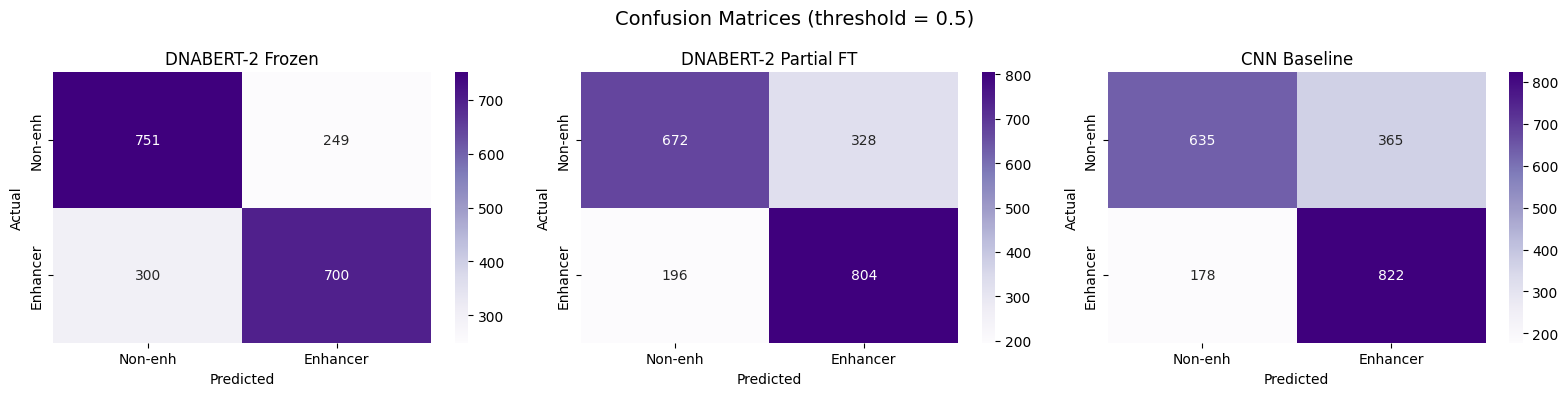

In [16]:
# ============================================================
# Step 8: Confusion matrices
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, mdl, ldr, mtype) in zip(axes, models_for_curves):
    probs, labels = get_predictions(mdl, ldr, mtype)
    preds = (probs >= 0.5).astype(int)
    cm = confusion_matrix(labels, preds)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
                xticklabels=['Non-enh', 'Enhancer'],
                yticklabels=['Non-enh', 'Enhancer'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(name)

plt.suptitle('Confusion Matrices (threshold = 0.5)', fontsize=14)
plt.tight_layout()
plt.show()

Per-Chromosome AUROC (DNABERT-2 Partial FT)
--------------------------------------------------
  chr19 (n=820): AUROC=0.862, F1=0.772
  chr20 (n=360): AUROC=0.801, F1=0.724
  chr21 (n=115): AUROC=0.798, F1=0.710
  chr22 (n=267): AUROC=0.804, F1=0.775
  chrX (n=438): AUROC=0.842, F1=0.737


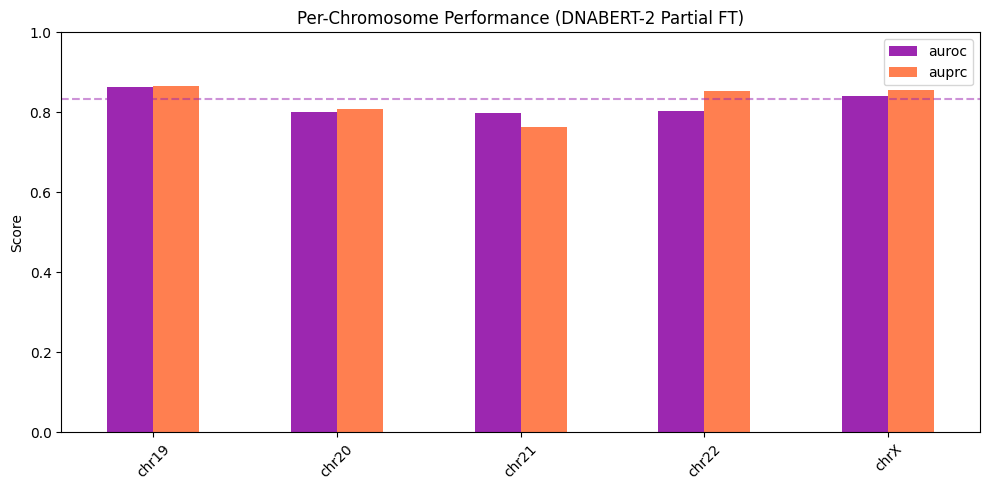

In [17]:
# ============================================================
# Step 8: Per-chromosome AUROC (using TRAINED model)
# ============================================================

print('Per-Chromosome AUROC (DNABERT-2 Partial FT)')
print('-' * 50)

chrom_results = {}
for chrom in test_chroms:
    subset = test_df[test_df.chrom == chrom]
    if len(subset) < 20 or subset.label.nunique() < 2:
        print(f'  {chrom}: skipped (n={len(subset)}, need both classes)')
        continue

    ldr = DataLoader(DNABERT2Dataset(subset), batch_size=BATCH_SIZE)
    metrics = evaluate(gfm_model, ldr, model_type='gfm')
    chrom_results[chrom] = metrics
    print(f'  {chrom} (n={len(subset):,}): AUROC={metrics["auroc"]:.3f}, F1={metrics["f1"]:.3f}')

if chrom_results:
    chrom_df = pd.DataFrame(chrom_results).T
    fig, ax = plt.subplots(figsize=(10, 5))
    chrom_df[['auroc', 'auprc']].plot.bar(ax=ax, color=['#9C27B0', 'coral'])
    ax.axhline(y=partial_test['auroc'], color='#9C27B0', linestyle='--', alpha=0.5)
    ax.set_ylabel('Score')
    ax.set_title('Per-Chromosome Performance (DNABERT-2 Partial FT)')
    ax.set_ylim(0, 1)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Saliency / Attribution Analysis

> *Lecture: "Do high-saliency regions overlap known enhancer motifs?"*

Same approach as previous notebooks: Integrated Gradients on the CNN baseline.
The CNN provides cleaner gradients for attribution analysis than transformer models.

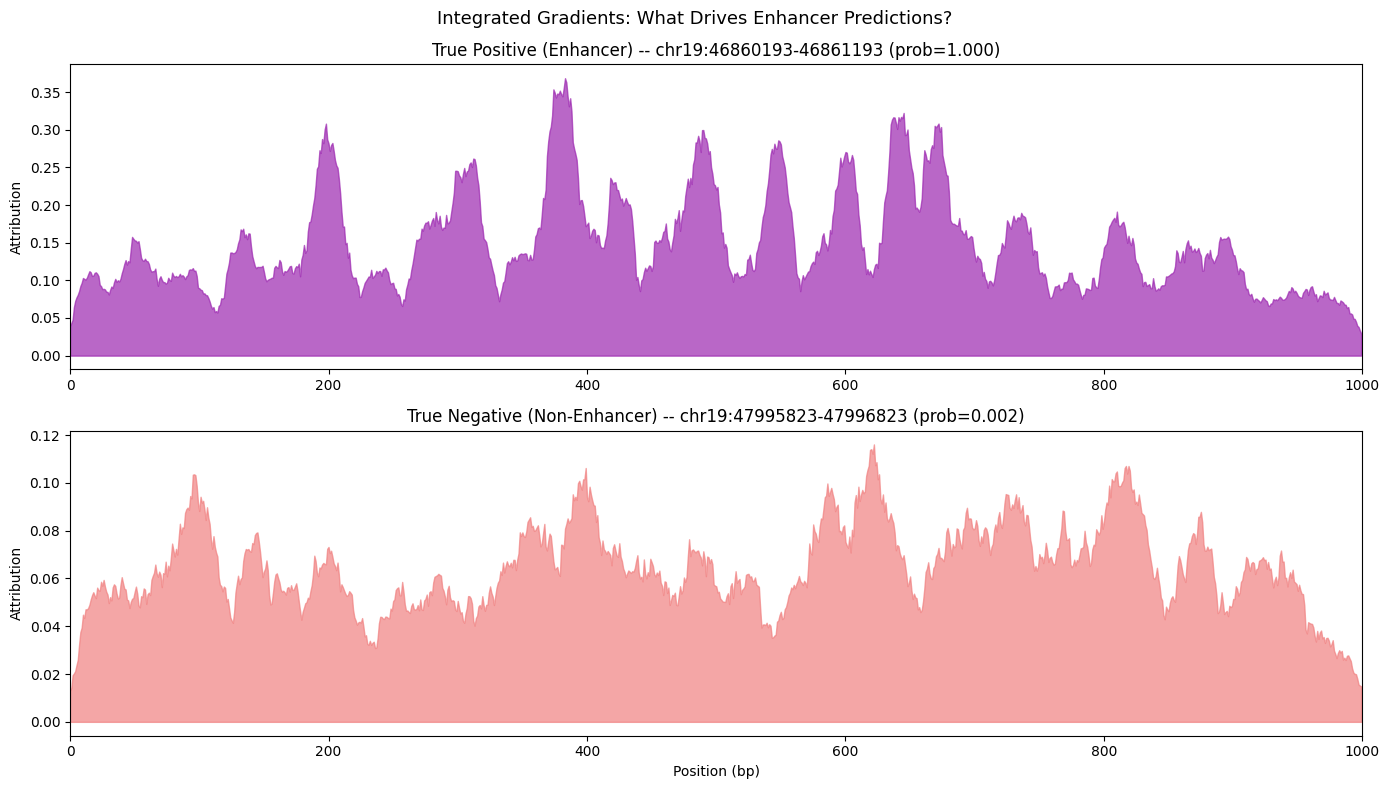

In [18]:
# ============================================================
# Step 8: Saliency analysis (Integrated Gradients on CNN)
# ============================================================

cnn_model.eval()

probs_cnn, labels_cnn = get_predictions(cnn_model, test_loader_cnn, 'cnn')
preds_cnn = (probs_cnn >= 0.5).astype(int)

tp_mask = (labels_cnn == 1) & (preds_cnn == 1)
tn_mask = (labels_cnn == 0) & (preds_cnn == 0)
tp_indices = np.where(tp_mask)[0]
tn_indices = np.where(tn_mask)[0]

if len(tp_indices) == 0 or len(tn_indices) == 0:
    print('Not enough correct predictions for saliency analysis')
else:
    tp_idx = tp_indices[probs_cnn[tp_indices].argmax()]
    tn_idx = tn_indices[probs_cnn[tn_indices].argmin()]

    ig = IntegratedGradients(cnn_model)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    for ax, idx, title, color in [
        (axes[0], tp_idx, 'True Positive (Enhancer)', '#9C27B0'),
        (axes[1], tn_idx, 'True Negative (Non-Enhancer)', 'lightcoral'),
    ]:
        row = test_df.iloc[idx]
        encoded = torch.tensor(
            one_hot_encode(row.sequence), dtype=torch.float32
        ).unsqueeze(0).to(device)
        encoded.requires_grad_(True)

        attrs = ig.attribute(encoded, n_steps=50)
        importance = np.abs(attrs.squeeze().cpu().detach().numpy()).sum(axis=0)
        smoothed = np.convolve(importance, np.ones(20)/20, mode='same')

        ax.fill_between(range(len(smoothed)), smoothed, alpha=0.7, color=color)
        pred_prob = probs_cnn[idx]
        ax.set_title(f'{title} -- {row.chrom}:{row.win_start}-{row.win_end} '
                     f'(prob={pred_prob:.3f})')
        ax.set_ylabel('Attribution')
        ax.set_xlim(0, len(smoothed))

    axes[1].set_xlabel('Position (bp)')
    plt.suptitle('Integrated Gradients: What Drives Enhancer Predictions?', fontsize=13)
    plt.tight_layout()
    plt.show()

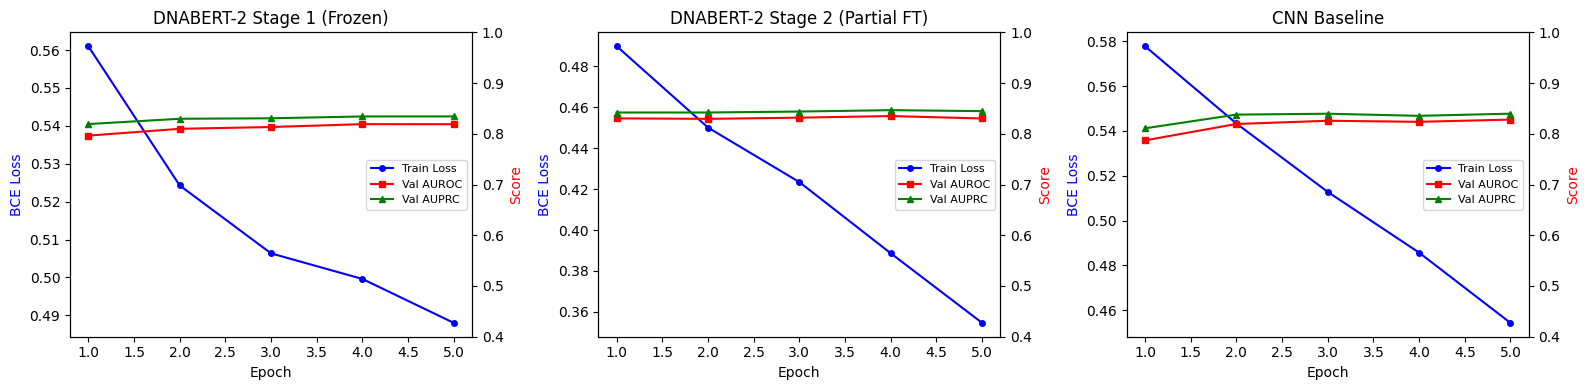

In [19]:
# ============================================================
# Training curves
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (title, hist) in zip(axes, [
    ('DNABERT-2 Stage 1 (Frozen)', history_s1),
    ('DNABERT-2 Stage 2 (Partial FT)', history_s2),
    ('CNN Baseline', history_cnn),
]):
    epochs = range(1, len(hist['train_loss']) + 1)
    ax2 = ax.twinx()
    ax.plot(epochs, hist['train_loss'], 'b-o', markersize=4, label='Train Loss')
    ax2.plot(epochs, hist['val_auroc'], 'r-s', markersize=4, label='Val AUROC')
    ax2.plot(epochs, hist['val_auprc'], 'g-^', markersize=4, label='Val AUPRC')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss', color='b')
    ax2.set_ylabel('Score', color='r')
    ax2.set_ylim(0.4, 1.0)
    ax.set_title(title)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=8)

plt.tight_layout()
plt.show()

## Cross-Model Comparison: DNABERT-2 vs NT vs HyenaDNA

After running all three classification notebooks, you can compare results.
Fill in the table below with your results:

### Results template

| Model | Params | Tokenization | Test AUROC | Test AUPRC | Test F1 |
|-------|-------:|-------------|:----------:|:----------:|:-------:|
| CNN Baseline | 105K | One-hot | ___ | ___ | ___ |
| **DNABERT-2** (frozen) | 117M | BPE | ___ | ___ | ___ |
| **DNABERT-2** (partial FT) | 117M | BPE | ___ | ___ | ___ |
| **NT-500M** (frozen) | 500M | 6-mer | ___ | ___ | ___ |
| **NT-500M** (partial FT) | 500M | 6-mer | ___ | ___ | ___ |
| **HyenaDNA-medium** (frozen) | 14.2M | Character | ___ | ___ | ___ |
| **HyenaDNA-medium** (partial FT) | 14.2M | Character | ___ | ___ | ___ |

### Discussion questions

1. **Does model size correlate with performance?** NT has 500M params, DNABERT-2 has
   117M, HyenaDNA has 14.2M. Does bigger = better for this task?

2. **Does tokenization matter?** BPE vs k-mer vs character-level — do they lead
   to meaningfully different results, or does the biological signal dominate?

3. **Efficiency vs performance:** If all models achieve similar AUROC, which would
   you choose for a production deployment? Consider training time, inference speed,
   and GPU memory.

4. **Pre-training data:** DNABERT-2 was pre-trained on multi-species genomes,
   while NT and HyenaDNA used human reference. Does multi-species pre-training
   help or hurt for a human-specific task?

5. **Staged fine-tuning:** Does partial unfreezing help all models equally, or
   do some benefit more than others? What might explain the differences?

## Summary

### What's Different in This Notebook

| Aspect | Change from NT Classification |
|--------|------------------------------|
| **Model** | DNABERT-2 (117M) instead of NT (500M) |
| **Tokenization** | BPE (learned, variable-length) instead of 6-mer (fixed) |
| **trust_remote_code** | Required for both tokenizer and model |
| **Backbone layers** | 12 (vs 24 for NT) |
| **Hidden size** | 768 (vs 1024 for NT) |
| **Everything else** | Identical — same data, splits, metrics, training loop |

### Key Takeaways

1. **Swapping GFMs is straightforward** — the classification head, training loop,
   and evaluation code are model-agnostic. Only the tokenizer and model loading change.

2. **Tokenization is an implicit hypothesis** — BPE assumes frequent substrings are
   meaningful, k-mers assume fixed-length units matter, character-level assumes nothing.
   The "right" choice depends on your biological question.

3. **Smaller models can be competitive** — DNABERT-2's 117M params may match or
   approach NT-500M's performance while being much faster to fine-tune.

4. **The canonical workflow (Steps 0-8) is model-independent** — this is the
   lecture's central message. Once you have the framework, evaluating a new model
   is mostly a matter of changing two lines of code.

### What to Try Next

- **Full fine-tuning:** With only 117M params, DNABERT-2 may benefit from
  unfreezing all layers (unlike NT-500M where this risks overfitting)
- **Longer sequences:** DNABERT-2 supports up to 512 tokens; try 2kb or 5kb windows
- **Cross-species transfer:** DNABERT-2 was pre-trained on multi-species data —
  test on mouse or fly enhancers without fine-tuning